# Sharp interfaces and the Spectral Element Method (SEM)
I'll write something more informative about Gibbs oscilation etc when this needs to be finalized.

In [1]:
# Square size and resolution of cartesian mesh
square_size = 2
n_pts = 300

# Path locations
results_path = "../../../results/brinkman_parameters/dt_check/"
Brinkman_path = "brinkman/"
stats_file = "brinkman0"

## PyNekTools

All information about PyNekTools can be found:

https://github.com/ExtremeFLOW/pyNekTools

If you don't have access you can contact Bertie, but if you have access to `neko` you should have access to this.

In [2]:
# Import required modules
from mpi4py import MPI #equivalent to the use of MPI_init() in C
import matplotlib.pyplot as plt
import numpy as np

# Get mpi info
comm = MPI.COMM_WORLD

# Hide the log for the notebook. Not recommended when running in clusters as it is better you see what happens
import os
os.environ["PYNEKTOOLS_HIDE_LOG"] = 'true'

from pynektools.io.ppymech.neksuite import pynekread
from pynektools.datatypes.msh import Mesh
from pynektools.datatypes.coef import Coef
from pynektools.datatypes.field import FieldRegistry
from pynektools.postprocessing.file_indexing import index_files_from_folder

## Design field
First we'll look at the wiggles in the design field.

We map the design indication $\rho \in [0,1]$ to the Brinkman coefficent $\chi(\rho) \in [0, \bar{\chi}]$  based on the mappings $\rho \mapsto \tilde{\rho} \mapsto \chi$ where $\tilde{\rho}$ is an intermediate filtering stage used to eliviate sharp interfaces in the design, known to result in undesirable Gibbs oscilation when using higher order methods.

**Note:** The design field `brinkman0.f00000` outputted from `neko` has the structure:

- $u$ corresponds to unfiltered design $\rho$
- $v$ corresponds to the filtered design $\tilde{\rho}$
- $w$ corresponds to the Brinkman coefficient $\chi$ 

In [3]:
brinkman_msh = Mesh(comm, create_connectivity=True)
brinkman_fld = FieldRegistry(comm)

# remember the mesh is only stored in the first one!
# here we're just getting the mesh
fname = results_path + Brinkman_path + stats_file + '/' + stats_file +'.f00000'
pynekread(fname, comm, data_dtype=np.double, msh=brinkman_msh, fld=brinkman_fld)

In `neko`, the data in the `*.f*` files is stored at the Gauss-Lobatto-Legendre (GLL) quadrature points, hence if one was to visualize $\rho$ in `Visit` or `Paraview`, a linear interpolation between the GLL points would be displayed.

However, using the SEM, the solution field is represented by the tensor product of Lagrangian polynomials which are continuous within each element. Hence, if one wishes to see the Gibbs oscilations asociated with representing sharp interfaces with high order polynomials a spectral interpolation onto a cartesian mesh must be performed.

In [4]:
from pynektools.interpolation.probes import Probes
import pynektools.interpolation.utils as interp_utils
import pynektools.interpolation.pointclouds as pcs



# Here we set up the uniform cartesian mesh around the cylinder
limits = [-square_size, square_size]
if comm.Get_rank() == 0 :
    # Wake line
    y_1d = pcs.generate_1d_arrays(limits, n_pts, mode="equal")
    x_1d = pcs.generate_1d_arrays(limits, n_pts, mode="equal")
    z_1d = [0.5]
    x, y, z = np.meshgrid(x_1d, y_1d, z_1d, indexing='ij')
    # Write the points for future use
    xyz = interp_utils.transform_from_array_to_list(n_pts, n_pts, 1, [x, y, z])
else:
    xyz = None

# Here we set up the probes
brinkman_probes = Probes(comm, probes = xyz, msh = brinkman_msh, point_interpolator_type='multiple_point_legendre_numpy', \
                         max_pts=256, find_points_comm_pattern='point_to_point')

# Here we probe both the unfiltered and filtered design fields
brinkman_probes.interpolate_from_field_list(0, [brinkman_fld.registry['u']], comm, write_data=False) # unfiltered
int_fields = interp_utils.transform_from_list_to_array(n_pts,n_pts,1,brinkman_probes.interpolated_fields)
unfiltered_int = np.copy(int_fields[1])

brinkman_probes.interpolate_from_field_list(0, [brinkman_fld.registry['v']], comm, write_data=False) # filtered
int_fields = interp_utils.transform_from_list_to_array(n_pts,n_pts,1,brinkman_probes.interpolated_fields)
filtered_int = np.copy(int_fields[1])


### Gibbs oscilation
If we compare the plots that have been linearly interpolated with those that have been spectrally interpolated, the "wiggles" become very apparant.

On the left we have a linear interpolation between GLL points, and on the right we have a spectral interpolation onto a fine cartesian grid to reveal the continous (and oscilatory) nature of the underlying polynomial functions.

Text(0.5, 1.0, '$\\rho$ (Spectrally interpolated)')

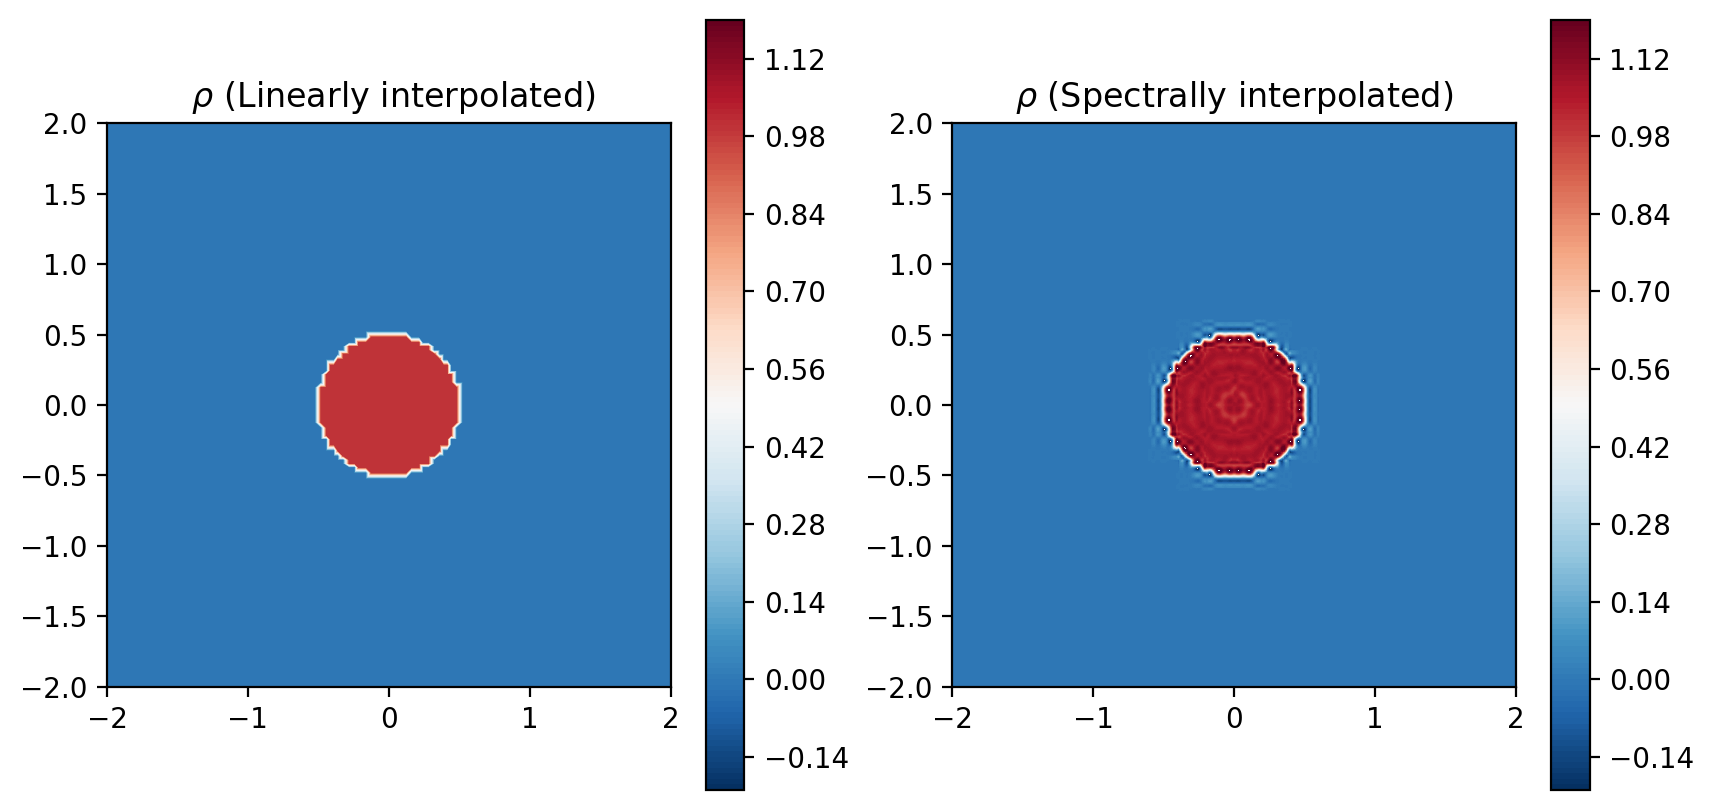

In [6]:
# find a plane somewhere in the middle
z_GLL = np.unique(brinkman_msh.z)
z_plane_index = np.where(brinkman_msh.z == z_GLL[2])


# we should have a nice colourbar
import matplotlib.colors as clr
cvals  = [-0.2, 0, 1, 1.2]
colors = ["blue","white","black", "red"]
tuples = list(zip(cvals, colors))
cmap = clr.LinearSegmentedColormap.from_list("", tuples)
# I haven't figured out how to do this nicely so I give up tehehe
cmap = 'RdBu_r'

fig, ax = plt.subplots(1,2, figsize=(10, 5), dpi = 200)

# plot the linearly interpolated plane
c = ax[0].tricontourf(brinkman_msh.x[z_plane_index].flatten(), brinkman_msh.y[z_plane_index].flatten() , \
                      brinkman_fld.registry["u"][z_plane_index].flatten(), cmap=cmap, levels=np.arange(start=-0.2, stop=1.2, step=0.01))
fig.colorbar(c)
ax[0].set_aspect('equal')
ax[0].set_xlim(limits)
ax[0].set_ylim(limits)
ax[0].set_title(r' $\rho$ (Linearly interpolated)')

# plot the spectrally interpolated plane
c = ax[1].tricontourf(x.flatten(), y.flatten() ,unfiltered_int.flatten(), cmap=cmap, levels=np.arange(start=-0.2, stop=1.2, step=0.01))
fig.colorbar(c)
ax[1].set_aspect('equal')
ax[1].set_xlim(limits)
ax[1].set_ylim(limits)
ax[1].set_title(r'$\rho$ (Spectrally interpolated)')

## PDE filtering

To avoid these Gibbs oscilations, a filtering $\rho \mapsto \tilde{\rho}$ is applied to the design field based on [Lazarov & O. Sigmund (2010)](https://doi.org/10.1002/nme.3072). This involves solving a PDE of the form

$ -r^2 \nabla^2 \tilde{\rho} + \tilde{\rho} = \rho, $

where $r$ denotes a filter radius.

Here we can see the smoothed design field $\tilde{\rho}$ exhibiting minimal oscilations.

Text(0.5, 1.0, '$\\tilde{\\rho}$ (Spectrally interpolated)')

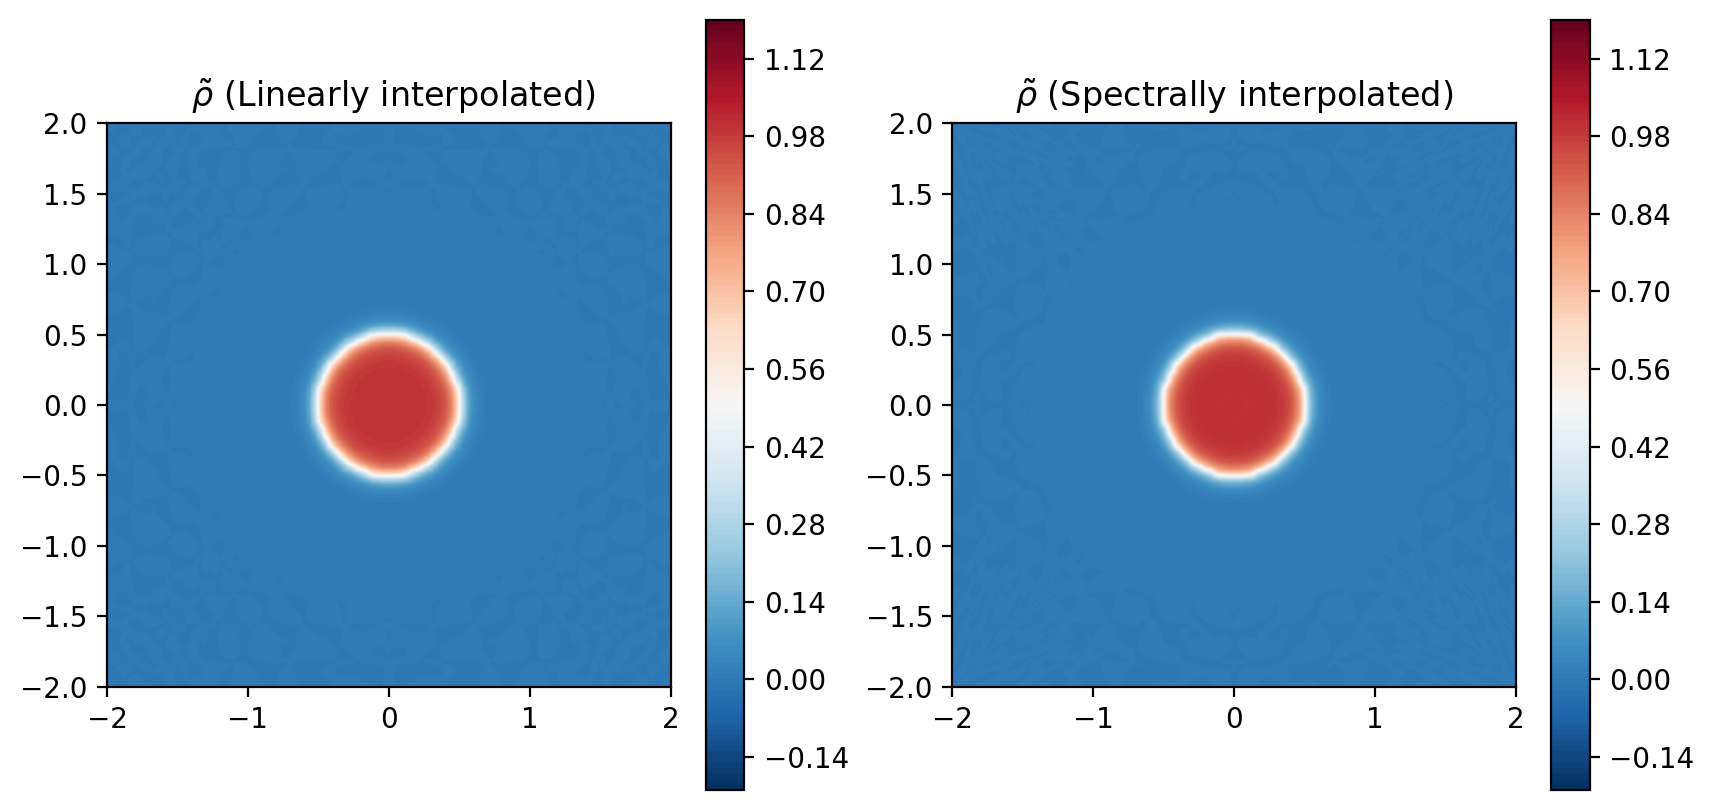

In [7]:
fig, ax = plt.subplots(1,2, figsize=(10, 5), dpi = 200)
# plot the linearly interpolated plane
c = ax[0].tricontourf(brinkman_msh.x[z_plane_index].flatten(), brinkman_msh.y[z_plane_index].flatten() , \
                      brinkman_fld.registry["v"][z_plane_index].flatten(), cmap='RdBu_r', levels=np.arange(start=-0.2, stop=1.2, step=0.01))
fig.colorbar(c)
ax[0].set_aspect('equal')
ax[0].set_xlim(limits)
ax[0].set_ylim(limits)
ax[0].set_title(r' $\tilde{\rho}$ (Linearly interpolated)')

# plot the spectrally interpolated plane
c = ax[1].tricontourf(x.flatten(), y.flatten() ,filtered_int.flatten(), cmap='RdBu_r', levels=np.arange(start=-0.2, stop=1.2, step=0.01))
fig.colorbar(c)
ax[1].set_aspect('equal')
ax[1].set_xlim(limits)
ax[1].set_ylim(limits)
ax[1].set_title(r'$\tilde{\rho}$ (Spectrally interpolated)')